In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

### Task 1: Central Tendency & Dispersion
* Calculate mean, median, mode of Math_Score.

In [13]:
df = pd.read_csv("students_scores.csv")

math_mean = df["Math_Score"].mean()
math_median = df["Math_Score"].median()
math_mode = df["Math_Score"].mode()[0]
print("Mean:", math_mean)
print("Median:", math_median)
print("Mode:", math_mode)


Mean: 59.95652
Median: 59.9
Mode: 65.0


* Find range, variance, standard deviation of Science_Score.

In [14]:
sci_range = df["Science_Score"].max() - df["Science_Score"].min()
sci_var = df["Science_Score"].var()
sci_std = df["Science_Score"].std()
print("Range:", sci_range)
print("Variance:", sci_var)
print("Standard Deviation:", sci_std)

Range: 92.9
Variance: 197.69392542148475
Standard Deviation: 14.060367186581038


### Task 2: Probability Basics
* Find the probability of students passing (Pass_Fail = 1).

In [15]:
p_pass = df["Pass_Fail"].mean()
print("P(Pass):", p_pass)

P(Pass): 0.7294


* Create a contingency table between Pass_Fail and Hours_Studied > 5.

In [16]:
df["Studied_gt_5"] = df["Hours_Studied"] > 5
contingency = pd.crosstab(df["Pass_Fail"], df["Studied_gt_5"])
print(contingency)

Studied_gt_5  False  True 
Pass_Fail                 
0               642    711
1              1962   1685


* Calculate conditional probability: P(Pass | Hours_Studied > 5).

In [17]:
subset = df[df["Studied_gt_5"] == True]
p_pass_given_studied = subset["Pass_Fail"].mean()
print("P(Pass | Hours>5):", p_pass_given_studied)

P(Pass | Hours>5): 0.7032554257095158


### Task 3: Distribution & Visualization
* Plot a Histogram & Normal curve for Math_Score.

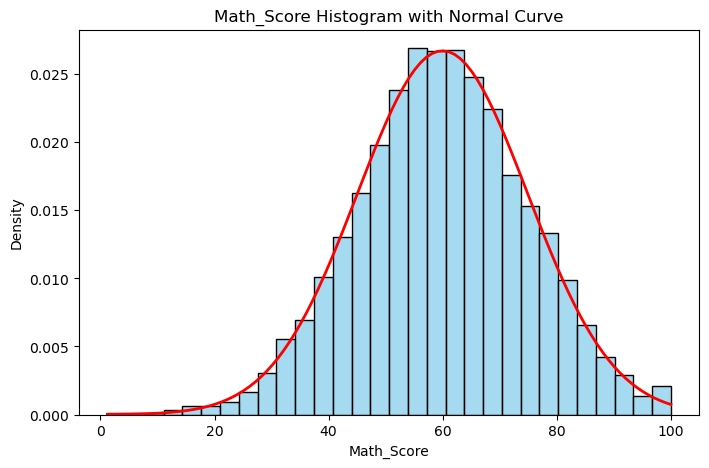

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Math_Score"], kde=False, stat="density", bins=30, color="skyblue")
mu, sigma = df["Math_Score"].mean(), df["Math_Score"].std()
x = np.linspace(df["Math_Score"].min(), df["Math_Score"].max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
plt.title("Math_Score Histogram with Normal Curve")
plt.savefig("math_hist.png")
plt.show()

* Calculate Skewness & Kurtosis for Science_Score.

In [19]:
skewness = df["Science_Score"].skew()
kurtosis = df["Science_Score"].kurt()
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: -0.016202640190253637
Kurtosis: -0.01962364243457282


* Perform a Q-Q Plot for English_Score.

Skewness: -0.016202640190253637
Kurtosis: -0.01962364243457282


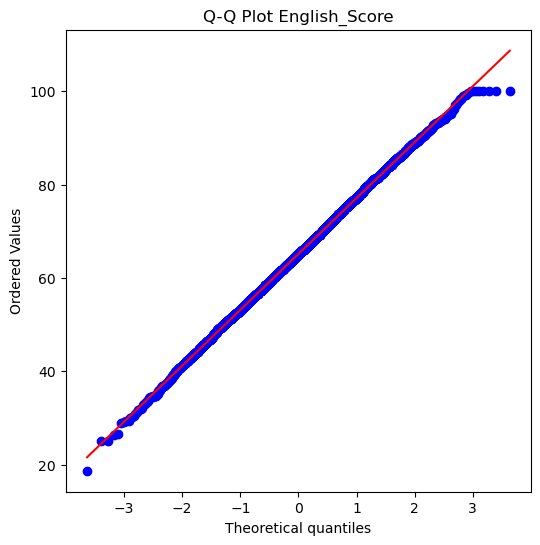

In [20]:
skewness = df["Science_Score"].skew()
kurtosis = df["Science_Score"].kurt()
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

plt.figure(figsize=(6,6))
stats.probplot(df["English_Score"], dist="norm", plot=plt)
plt.title("Q-Q Plot English_Score")
plt.savefig("qq_english.png")
plt.show()

### Task 4: Linear Algebra Mini Task
* Represent Math_Score and Science_Score of first 5 students as vectors.

In [23]:
v_math = df["Math_Score"].values[:5]
v_sci = df["Science_Score"].values[:5]
print("Math_Score values:", v_math)
print("Science_Score values:", v_sci)

Math_Score values: [67.5 54.9 62.9 68.1 51.3]
Science_Score values: [41.2 44.1 46.4 58.7 59.1]


* Dot product of the two vectors.

In [24]:
dot_product = np.dot(v_math, v_sci)

print("Dot Product:", dot_product)

Dot Product: 15149.95


* Norm 1 and Norm 2 of Math_Score vector.

In [25]:
norm1 = np.linalg.norm(v_math, ord=1)
norm2 = np.linalg.norm(v_math, ord=2)

print("Norm1:", norm1, "Norm2:", norm2)

Norm1: 304.7 Norm2: 137.09839532248364


* Find angle between the two vectors.

In [26]:
cos_theta = dot_product / (np.linalg.norm(v_math) * np.linalg.norm(v_sci))
angle = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print("Angle:", angle, "degrees")

Angle: 11.687360867230236 degrees
